In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('../datasets/cleaned_data/cleaned_cars_info.csv')
df.head(2)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,Combined (L/100 km),CO2 emissions (g/km)
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,8.3,191
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,9.3,214


#### Univariate Analysis on Numerical Columns

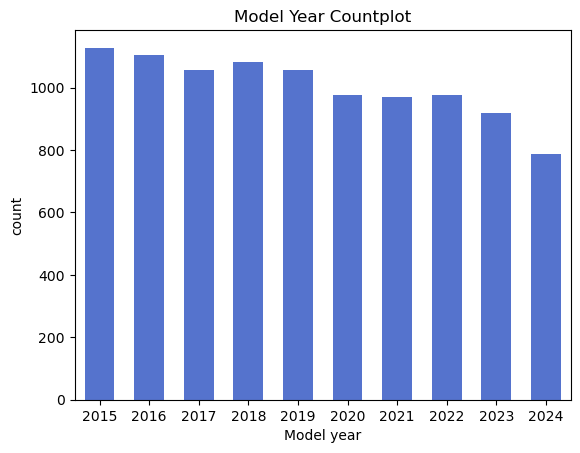

In [4]:
sns.countplot(data = df, x = 'Model year', color = 'royalblue', width = 0.6)
plt.title('Model Year Countplot')
plt.show()

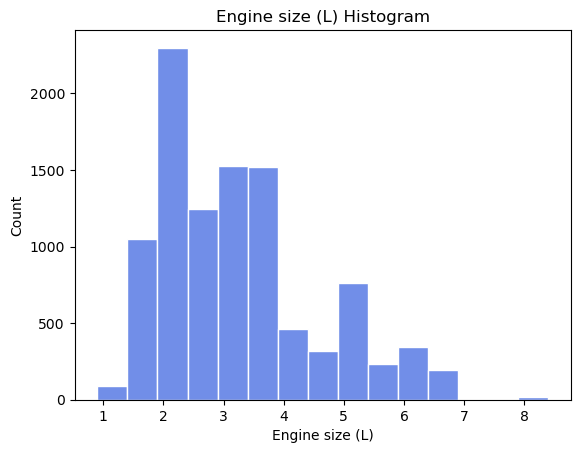

In [5]:
sns.histplot(data = df, x = 'Engine size (L)', color = 'royalblue', bins = 15, edgecolor = 'white')
plt.title('Engine size (L) Histogram')
plt.show()

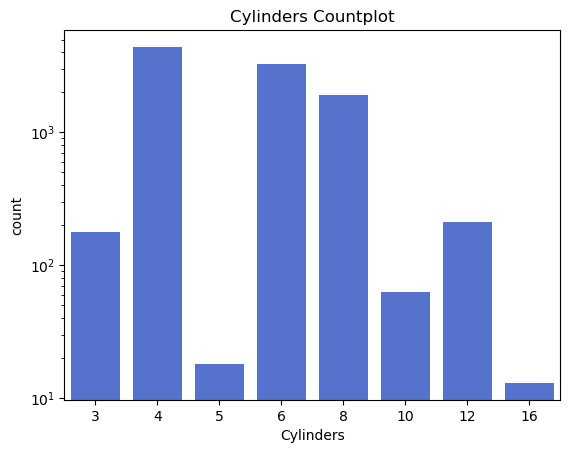

In [6]:
sns.countplot(data = df, x = 'Cylinders', log = True, color = 'royalblue')
# plt.ylim(0,30)
plt.title('Cylinders Countplot')
plt.show()

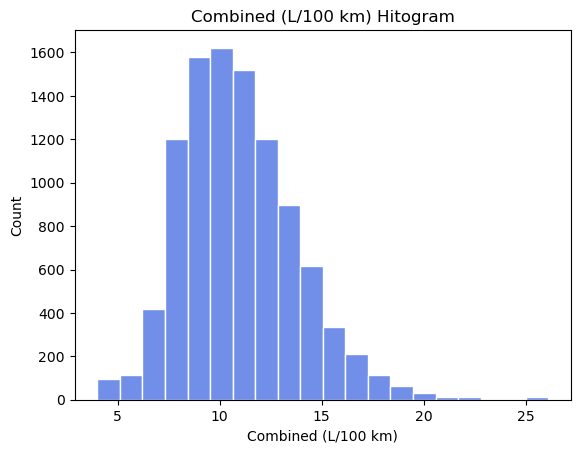

In [7]:
sns.histplot(data = df, x = 'Combined (L/100 km)', color = 'royalblue', bins = 20, edgecolor = 'white')
plt.title('Combined (L/100 km) Hitogram')
plt.show()

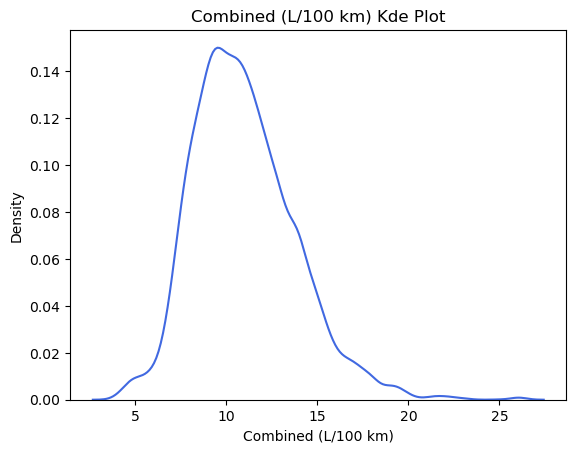

In [8]:
sns.kdeplot(data = df, x = 'Combined (L/100 km)', color = 'royalblue')
plt.title('Combined (L/100 km) Kde Plot')
plt.show()

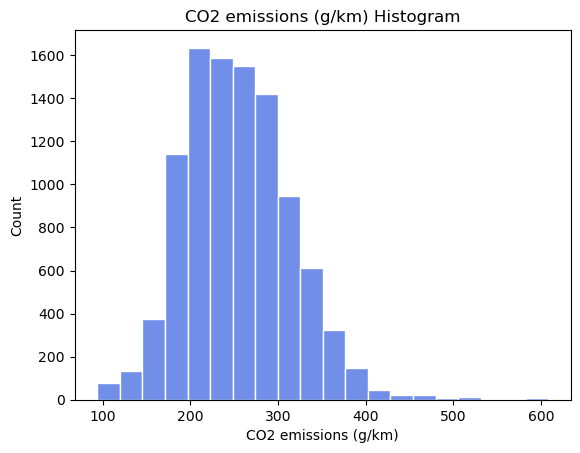

In [9]:
sns.histplot(data = df, x = 'CO2 emissions (g/km)', color = 'royalblue', bins = 20, edgecolor = 'white')
plt.title('CO2 emissions (g/km) Histogram')
plt.show()

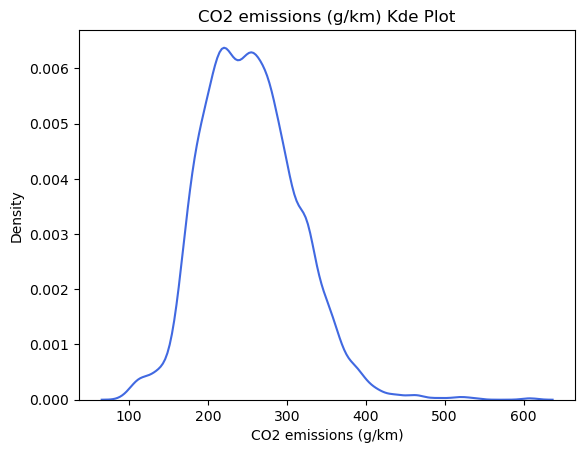

In [10]:
sns.kdeplot(data = df, x = 'CO2 emissions (g/km)', color = 'royalblue')
plt.title('CO2 emissions (g/km) Kde Plot')
plt.show()

#### Key Points

Model Year
- Dataset spans 2015–2024
- Count gradually decreases over years; 2024 is lowest likely because dataset was collected before all 2024 models were released

Engine Size (L)
- Right skewed distribution
- 2L engines are most common, reflects industry trend toward smaller turbocharged engines for better fuel efficiency

Cylinders
- Discrete column so countplot was used instead of histogram
- 4 and 6 cylinders dominate
- Log scale was necessary because rare cylinder counts (3, 5, 16) were nearly invisible on a linear scale

Combined (L/100 km)
- Right skewed distribution
- Peaks around 9–10 L/100 km which represents typical fuel consumption for regular passenger vehicles
- Long right tail driven by larger trucks and SUVs

CO2 Emissions (g/km)
- Right skewed, similar shape to Combined L/100 km — expected since the two are closely related
- KDE reveals a slight bimodal shape with peaks around 220 and 260 g/km
- Possible two clusters of vehicles — smaller passenger cars vs larger SUVs/trucks
- Worth investigating further in bivariate analysis

#### Univariate Analysis on Categorical Columns

In [11]:
df.head(2)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,Combined (L/100 km),CO2 emissions (g/km)
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,8.3,191
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,9.3,214


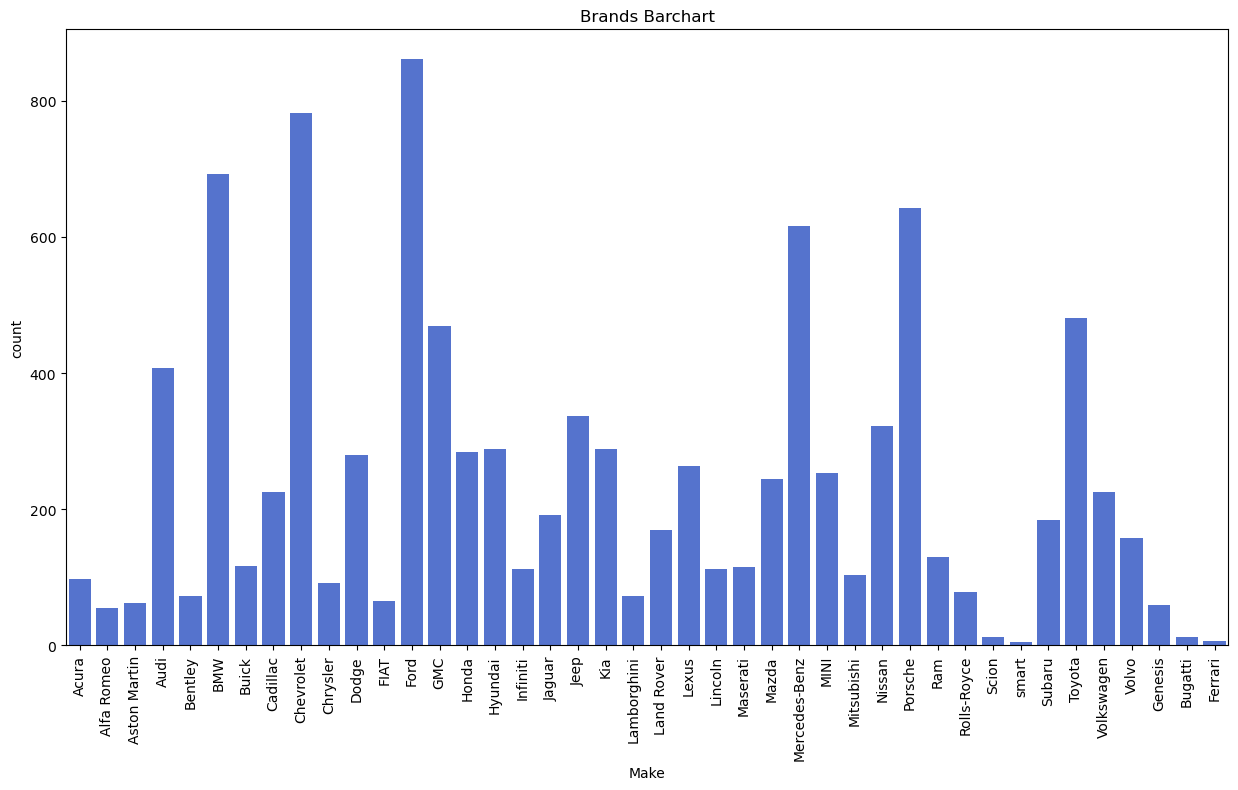

In [12]:
plt.figure(figsize = (15,8))
sns.countplot(data = df, x = 'Make', color = 'royalblue')
plt.xticks(rotation = 90)
plt.title('Brands Barchart')
plt.show()

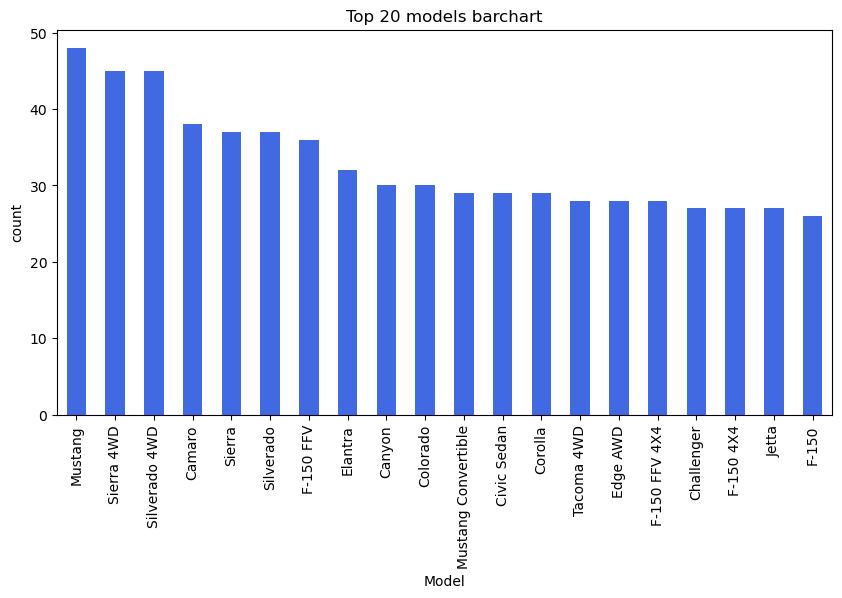

In [13]:
plt.figure(figsize = (10,5))
df['Model'].value_counts().head(20).plot(kind = 'bar', color = 'royalblue')
plt.ylabel('count') 
plt.title('Top 20 models barchart')
plt.show()

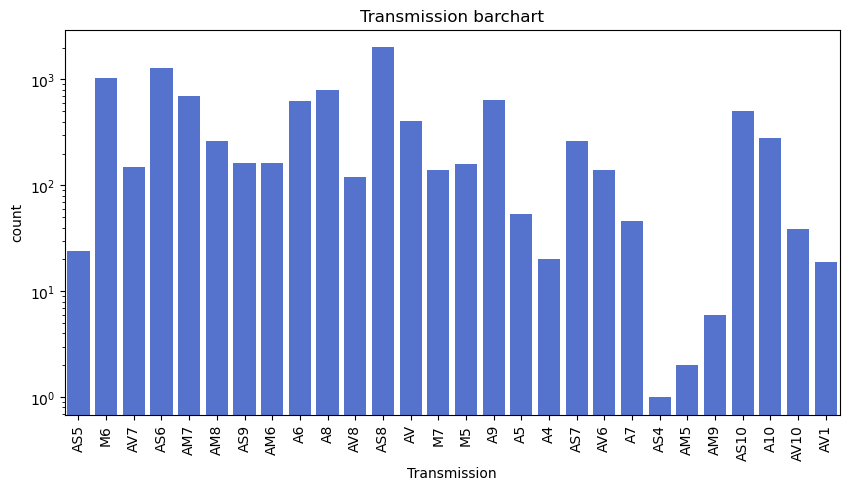

In [14]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'Transmission', color = 'royalblue', log = True)
plt.xticks(rotation = 90)
plt.title('Transmission barchart')
plt.show()

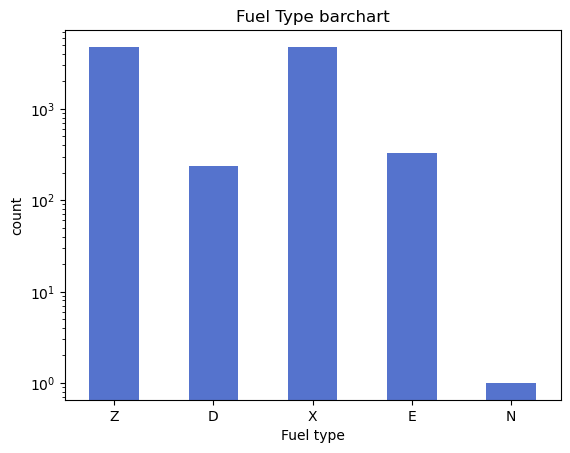

In [15]:
labels = {'Z': 'Premium', 'D': 'Diesel', 'X': 'Regular', 'E': 'E85', 'N': 'Natural Gas'}

fig = sns.countplot(data = df, x = 'Fuel type', color = 'royalblue', log = True, width = 0.5)
# fig.set_xticklabels([label for label in labels.values()])
plt.title('Fuel Type barchart')
plt.show()


#### Key Points

Make
- Distribution is non-uniform — Ford, Chevrolet, BMW and Porsche are the most represented brands
- Reflects Canadian market preference for American and European vehicles

Model
- Too many unique models to plot all so I have limited to top 20 for readability
- Mustang has the highest count, indicating strong American vehicle representation in the dataset
- Brands with higher overall counts naturally tend to have more models represented

Transmission
- Distribution is non-uniform with large count differences between transmission types
- Log scale was used to make lower frequency transmissions visible
- AS8 (8-speed automatic with select shift) is the most common which reflects modern vehicles favouring more gears for better fuel efficiency

Fuel Type
- Z (Premium Gasoline) and X (Regular Gasoline) dominate overwhelmingly
- E (E85 Ethanol) is surprisingly higher than D (Diesel) — Canada has a significant flex-fuel vehicle market
- N (Natural Gas) has 1 count — extremely rare in consumer vehicles
- Log scale was used due to the large gap between gasoline and other fuel types

#### Bivariate analysis

In [16]:
df.head(2)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,Combined (L/100 km),CO2 emissions (g/km)
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,8.3,191
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,9.3,214


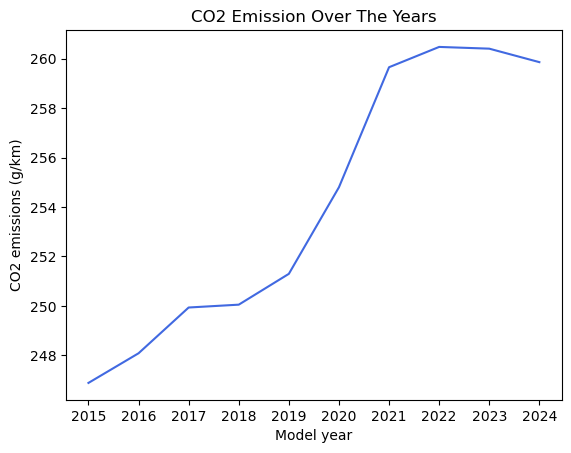

In [17]:
sns.lineplot(data = df, x = 'Model year', y = 'CO2 emissions (g/km)', color = 'royalblue', errorbar = None)
plt.xticks(range(2015, 2025))
plt.title('CO2 Emission Over The Years')
plt.show()

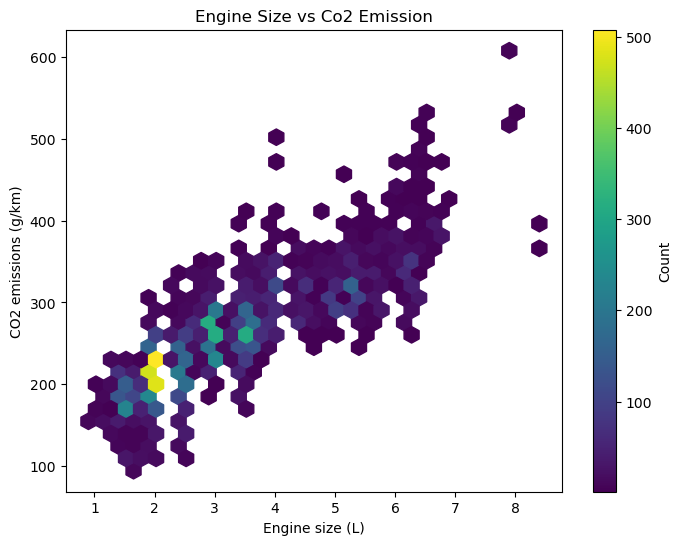

In [18]:
plt.figure(figsize = (8,6))
plt.hexbin(df['Engine size (L)'], df['CO2 emissions (g/km)'], gridsize = 30, cmap = 'viridis', mincnt = 1)
plt.colorbar(label = 'Count')
plt.xlabel('Engine size (L)')
plt.ylabel('CO2 emissions (g/km)')
plt.title('Engine Size vs Co2 Emission')
plt.show()

Interpretation:

1. There is a clear positive relationship between engine size and CO₂ emissions.

2. The relationship appears approximately linear.

3. Most vehicles in the dataset have engine sizes between 1.5 L and 3 L and corresponding CO₂ emissions around 180–260 g/km.

4. Vehicles with engine sizes above 7 L are relatively rare.The spread of CO₂ emissions increases for larger engine sizes, indicating
   greater variability among larger engine vehicles.

5. A few potential outliers are present at very high engine sizes and emission levels.

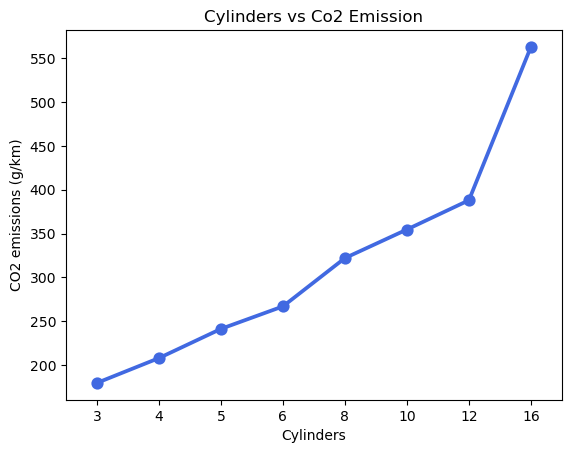

In [19]:
sns.pointplot(data = df, x = 'Cylinders', y = 'CO2 emissions (g/km)', errorbar = None, color = 'royalblue')
plt.title('Cylinders vs Co2 Emission')
plt.show()

Interpretation

1. Each dot represents the average Co2 realeased.

2. With the increase in the number of Cylinders Co2 emission increase.

3. Between 12-16 cylinders there is sudden spike indicating that 12-16 cylinders vehicles emits the highest co2.

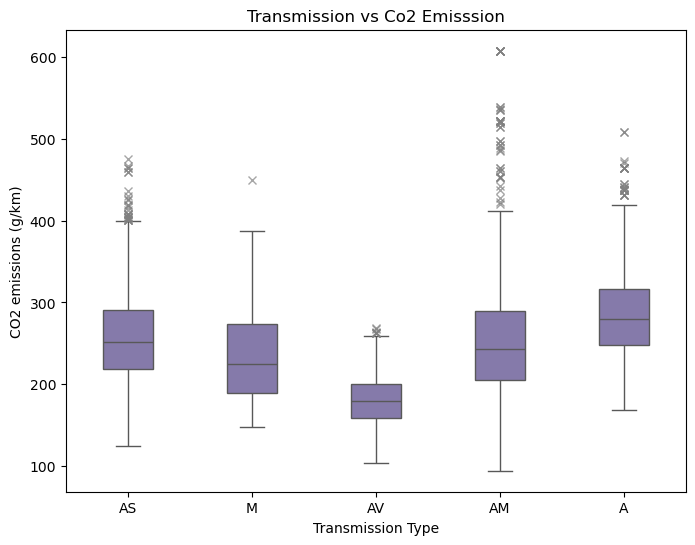

In [20]:
temp_trans_type = df['Transmission'].str.extract(r'([A-Za-z]+)')[0]
plt.figure(figsize = (8,6))
sns.boxplot(x = temp_trans_type, y = df['CO2 emissions (g/km)'], width = 0.4, color = '#8172B2', 
            flierprops = dict(alpha = 0.7, marker = 'x', markeredgecolor = 'grey', markersize = 6))

plt.xlabel('Transmission Type')
plt.title('Transmission vs Co2 Emisssion')
plt.show()

A = Automatic
AS = Automatic with Select Shift
M = Manual
AM = Automated Manual
AV = Continuously Variable Transmission (CVT / Auto Variable)

Interpretation

1. AV vehicles exhibit the lowest median CO₂ emissions and the smallest variability, suggesting consistently lower emissions.

2. Automatic (A) vehicles have the highest median CO₂ emissions among the transmission types.

3. AM vehicles display the widest spread in emissions and contain numerous extreme high-emission outliers, indicating substantial 
   heterogeneity.
   
4. All transmission types show overlapping distributions, implying that transmission type alone does not fully explain CO₂ emissions.

5. Most transmission categories exhibit slight right skewness, with a greater number of extreme high-emission vehicles than 
   low-emission vehicles.

6. The observed differences may also reflect underlying factors such as engine size, vehicle class, or fuel type, which should be
   investigated further.

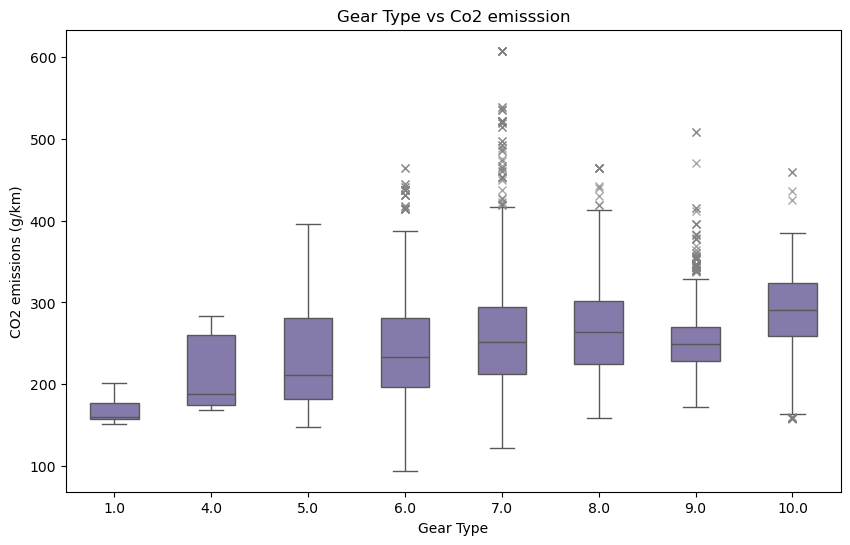

In [21]:
temp_gear_count = df['Transmission'].str.extract(r'(\d+)')[0].astype(float) # float to allow NaN for CVT, AV etc
plt.figure(figsize = (10,6))
sns.boxplot(x = temp_gear_count, y = df['CO2 emissions (g/km)'], width = 0.5, color = '#8172B2', flierprops = dict(alpha = 0.7, marker = 'x', markeredgecolor = 'grey', markersize = 6))

plt.xlabel('Gear Type')
plt.title('Gear Type vs Co2 emisssion')
plt.show()

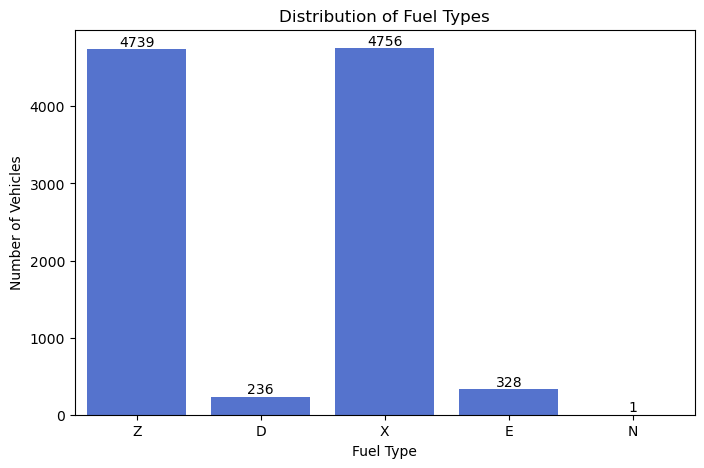

In [22]:
plt.figure(figsize = (8,5))

ax = sns.countplot(
    data = df,
    x = 'Fuel type',
    color ='royalblue'
)

# Annotate counts
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')

plt.show()

Key Insights:

1. Regular gasoline (X) and Premium gasoline (Z) dominate the dataset.
2. Ethanol (E) and Diesel (D) have relatively fewer observations.
3. Natural Gas (N) has only one observation, so conclusions about this category are unreliable.

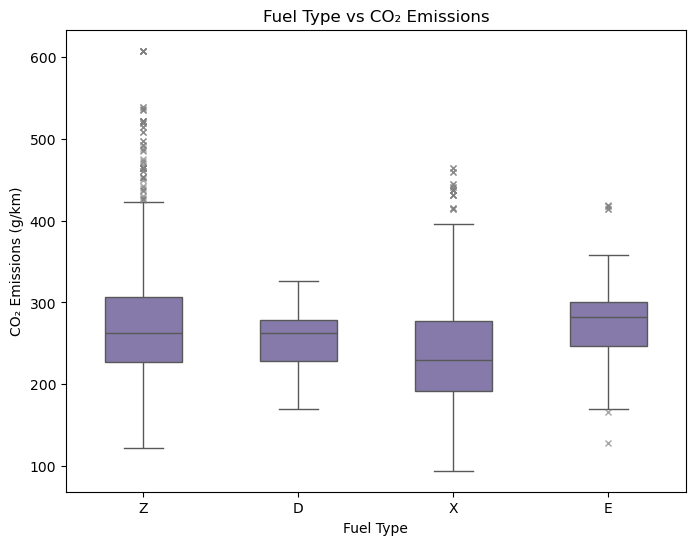

In [23]:
plt.figure(figsize=(8,6))

fuel_df = df[df['Fuel type'] != 'N']
sns.boxplot(
    data=fuel_df,
    x='Fuel type',
    y='CO2 emissions (g/km)',
    color='#8172B2',
    width=0.5,
    flierprops=dict(
        marker='x',
        markersize=5,
        markeredgecolor='gray',
        alpha=0.7
    )
)

plt.title('Fuel Type vs CO₂ Emissions')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')

plt.show()

Key Insights

1. Fuel type E has the highest median CO₂ emissions.
2. Fuel type D exhibits the largest variability.
3. Fuel types X and Z have overlapping distributions.
4. Fuel type N was excluded because it contains only one observation.

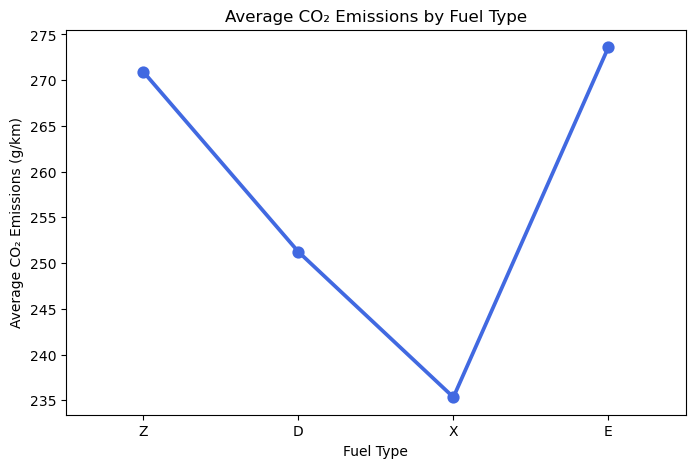

In [ ]:
plt.figure(figsize=(8,5))

sns.pointplot(
    data = fuel_df,
    x = 'Fuel type',
    y = 'CO2 emissions (g/km)',
    errorbar = None,
    color = 'royalblue'
)

plt.title('Average CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average CO₂ Emissions (g/km)')

plt.show()

Key Insights

1. E has the highest average CO₂ emissions.
2. X has a lower average than Z.
3. Differences in average emissions should be interpreted cautiously, as engine size and vehicle class may also influence emissions.

Z = premium gasoline
D = Diesel
X = normal gasoline
E = E85
N = Natural Gas

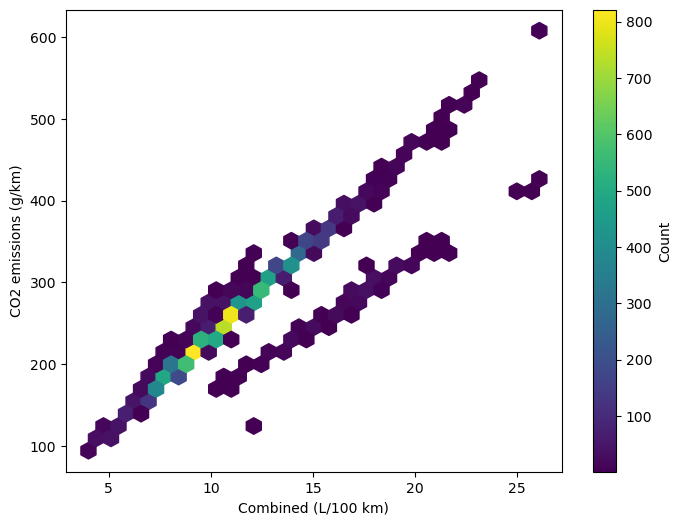

In [25]:
plt.figure(figsize = (8,6))
plt.hexbin(df['Combined (L/100 km)'], df['CO2 emissions (g/km)'], gridsize = 30, cmap = 'viridis', mincnt = 1)
plt.colorbar(label = 'Count')
plt.xlabel('Combined (L/100 km)')
plt.ylabel('CO2 emissions (g/km)')
plt.show()

In [26]:
df['Combined (L/100 km)'].corr(df['CO2 emissions (g/km)'])

np.float64(0.9446481114224865)

#### Multivariate Analysis

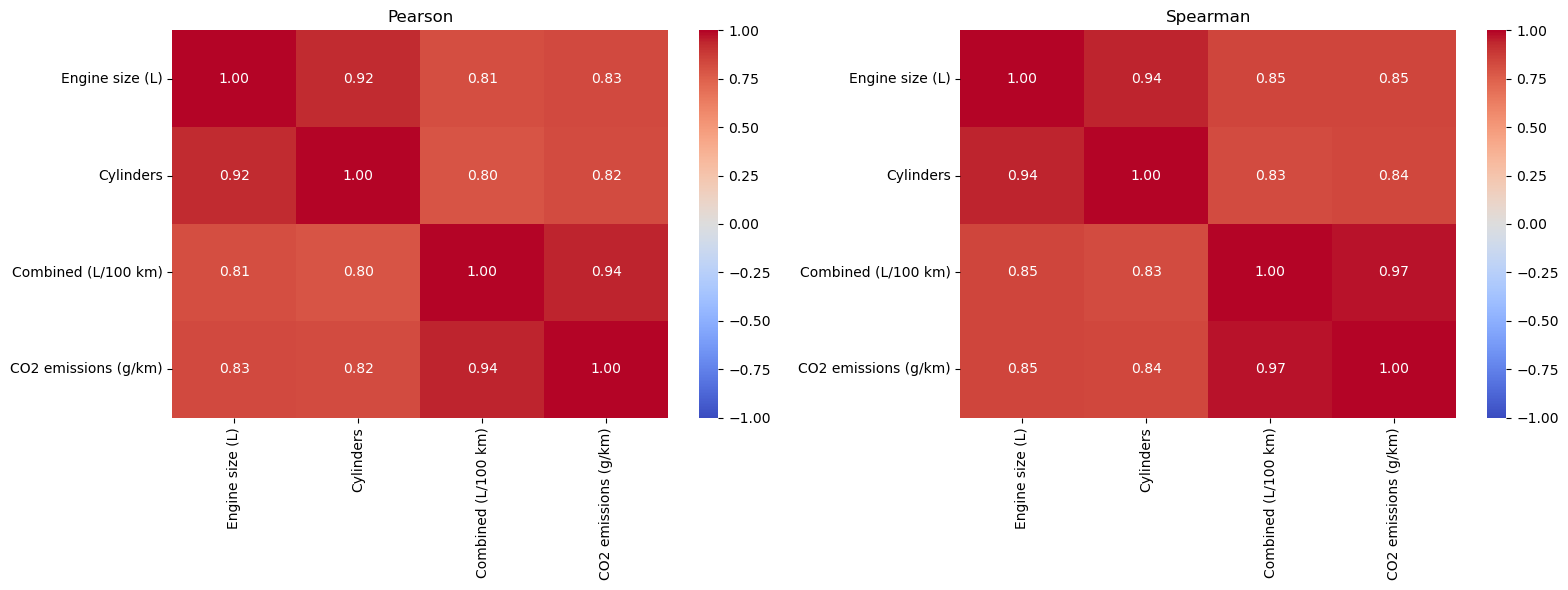

In [27]:
numeric_cols = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']

pearson_corr = df[numeric_cols].corr(method = 'pearson')
spearman_corr = df[numeric_cols].corr(method = 'spearman')

fig, axes = plt.subplots(1, 2, figsize = (16, 6))
sns.heatmap(pearson_corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1, ax = axes[0])
axes[0].set_title('Pearson')
sns.heatmap(spearman_corr, annot = True, fmt = '.2f', vmin = -1, vmax = 1, cmap = 'coolwarm', ax = axes[1])
axes[1].set_title('Spearman')
plt.tight_layout()
plt.show()

Key Insights:

1. Combined fuel consumption shows the strongest positive correlation with CO₂ emissions (Pearson: 0.94, Spearman: 0.97),
   indicatingthat vehicles consuming more fuel tend to emit substantially more CO₂.

2. Engine size and the number of cylinders are highly correlated (Pearson: 0.92), suggesting that larger engines are typically
   associated with more cylinders.

3. Engine size and cylinders both exhibit strong positive correlations with CO₂ emissions, although their relationships are
   slightly weaker than that of combined fuel consumption.

4. The similarity between Pearson and Spearman correlation coefficients across all variable pairs suggests that the
    relationships are predominantly linear, with minimal influence from outliers or strong nonlinear patterns.

In [28]:
fuel_df.groupby('Fuel type').apply(lambda grp:grp['Engine size (L)'].corr(grp['CO2 emissions (g/km)']), include_groups = False).reset_index().rename(columns = {0:'Correlation(Engine size vs CO2)'})

,Fuel type,Correlation(Engine size vs CO2)
0,D,0.801568
1,E,0.838475
2,X,0.811556
3,Z,0.834881


Key Insight:

The correlation remains consistently strong across all fuel types, indicating that engine size is a strong predictor of CO₂ emissions regardless of fuel type. Fuel type does not significantly alter this relationship.

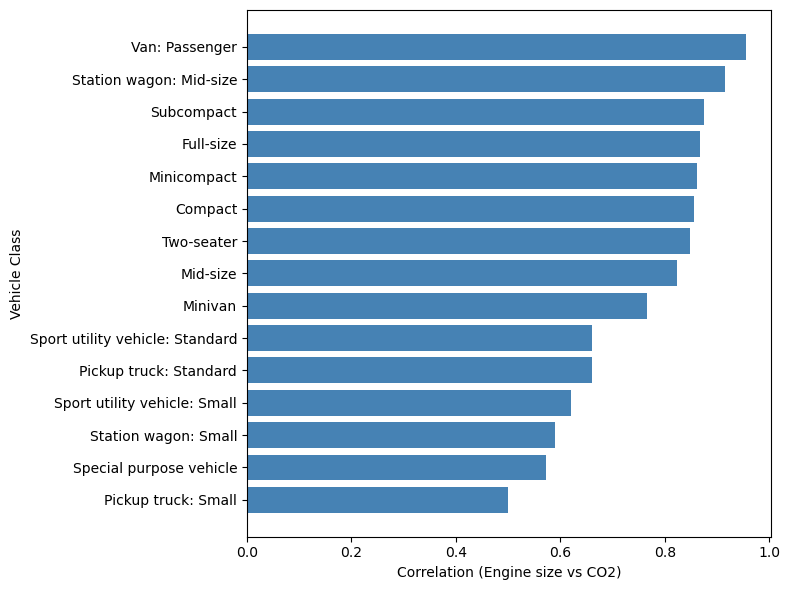

In [29]:
vehicle_class_corr = df.groupby(
    'Vehicle class').apply(lambda grp: grp['Engine size (L)'].corr(grp['CO2 emissions (g/km)']),
    include_groups = False
).reset_index().rename(columns = {0: 'Correlation'})

vehicle_class_corr = vehicle_class_corr.sort_values('Correlation')

plt.figure(figsize=(8, len(vehicle_class_corr) * 0.4))
plt.barh(vehicle_class_corr['Vehicle class'], vehicle_class_corr['Correlation'], color = 'steelblue')
plt.xlabel('Correlation (Engine size vs CO2)')
plt.ylabel('Vehicle Class')
plt.tight_layout()
plt.show()

Key insights:

1. The correlation between engine size and CO₂ emissions remains positive across all vehicle classes, indicating that larger engines
   generally produce higher CO₂ emissions regardless of vehicle category.

2. The strength of the correlation varies between vehicle classes, suggesting that the impact of engine size on CO₂ emissions is not 
   uniform across all categories.

3. Vehicle classes with higher correlation coefficients exhibit a more consistent linear relationship between engine size and CO₂
   emissions, while classes with lower correlations show greater variability, implying that additional factors may influence emissions within those categories.

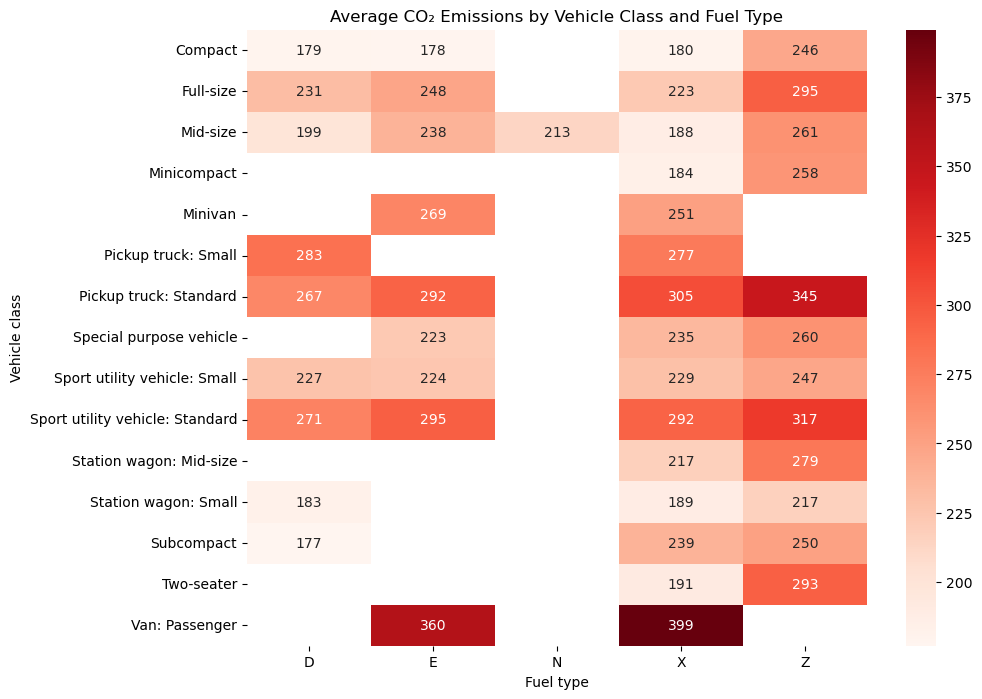

In [30]:
vehicle_fuel = (df.groupby(['Vehicle class', 'Fuel type'])['CO2 emissions (g/km)']
                .mean()
                .reset_index()
                .sort_values('CO2 emissions (g/km)', ascending = False)
)

plt.figure(figsize = (10,8))
sns.heatmap(vehicle_fuel.pivot(index = 'Vehicle class',
                               columns = 'Fuel type',
                               values = 'CO2 emissions (g/km)'),
                               annot = True,
                               cmap = 'Reds',
                               fmt = '.0f'
)

plt.title('Average CO₂ Emissions by Vehicle Class and Fuel Type')
plt.show()

Key Insights

1. Van: Passenger + X fuel has the highest average CO₂ emissions (399 g/km).

2. The next highest combinations are:
    - Van: Passenger + E (360 g/km)
    - Pickup truck: Standard + Z (345 g/km)
    - Sport utility vehicle: Standard + Z (317 g/km)
    - Pickup truck: Standard + X (305 g/km)

3. Larger vehicle classes (Passenger Vans, Standard Pickup Trucks, Standard SUVs) consistently produce higher emissions regardless of
   fuel type.

4. Compact, Subcompact and Station Wagon classes generally have much lower average CO₂ emissions.

5. Premium gasoline (Z) is associated with the highest average CO₂ emissions in the majority of vehicle classes, whereas diesel (D),
   ethanol (E), and regular gasoline (X) lead only in a few specific vehicle classes.

In [31]:
# plt.figure(figsize = (14,6))
# sns.boxplot(data = df, x = 'Vehicle class', y = 'CO2 emissions (g/km)', hue = 'Fuel type')
# plt.xticks(rotation = 90)
# plt.show()

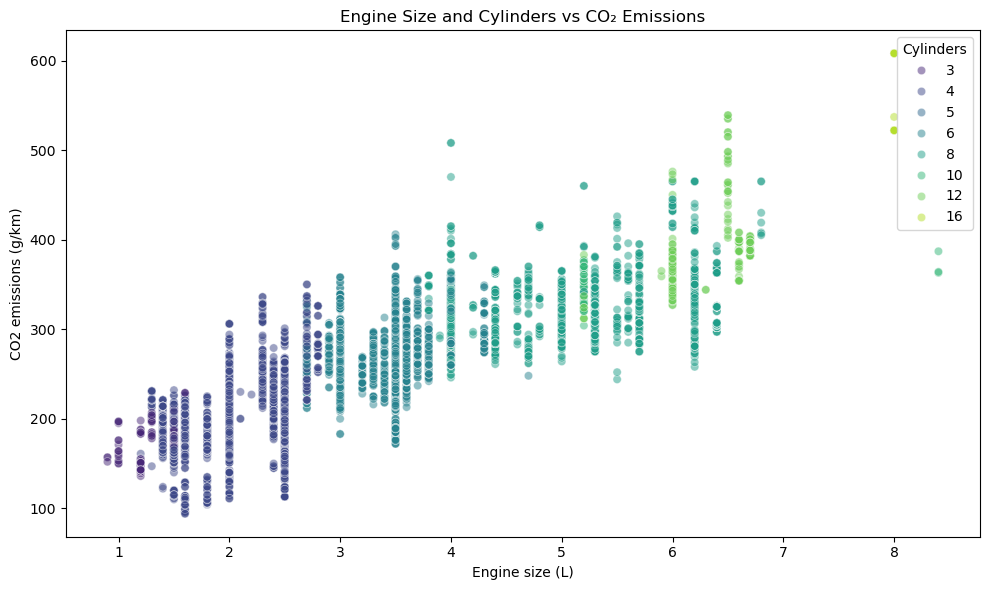

In [32]:
df_plot = df.copy()

# Order cylinders numerically so the legend makes sense (was sorting as text before)
df_plot['Cylinders'] = pd.Categorical(
    df_plot['Cylinders'],
    categories=sorted(df['Cylinders'].unique()),
    ordered=True
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x = 'Engine size (L)',
    y = 'CO2 emissions (g/km)',
    hue = 'Cylinders',
    palette = 'viridis',
    alpha = 0.5
)

plt.title('Engine Size and Cylinders vs CO₂ Emissions')
plt.tight_layout()
plt.show()

Key Insights

1. CO₂ emissions show a strong positive relationship with engine size, with larger engines generally producing higher emissions.
   Higher cylinder-count vehicles (10, 12, and 16 cylinders) are predominantly associated with larger engine sizes and higher CO₂ emissions.

2. The highest CO₂ emissions are observed in vehicles that combine large engine sizes (above 6 L) with high cylinder counts (12–16
   cylinders).

3. Vehicles with the same engine size exhibit varying CO₂ emission levels, indicating that factors beyond engine size and cylinders
   also influence emissions.

4. The overall upward trend suggests that engine size and cylinder count together are strong indicators of increased CO₂ emissions.